In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sea_clean_data.csv")
df.head()

,Unnamed: 0,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,1.0,0.82,True,5.0,5.0,True,True,Wallingford,47.65444,...,4.83,4.77,4.88,4.57,False,3,3,0,0,0.82
1,1,1.0,0.97,True,10.0,11.0,True,True,Georgetown,47.55017,...,4.92,4.89,4.70,4.69,False,10,0,10,0,1.19
2,3,1.0,0.82,True,5.0,5.0,True,True,Wallingford,47.65405,...,4.78,4.72,4.86,4.74,False,3,3,0,0,0.51
3,4,1.0,1.00,True,1.0,2.0,True,True,Whittier Heights,47.67947,...,4.98,4.98,4.90,4.90,True,1,1,0,0,6.06
4,5,1.0,0.00,False,1.0,1.0,False,True,Eastlake,47.63941,...,4.46,4.58,4.83,4.36,False,1,1,0,0,0.35


In [3]:
df = df.drop(columns=["Unnamed: 0"])

bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1.0,0.82,1,5.0,5.0,1,1,Wallingford,47.65444,-122.33629,...,4.83,4.77,4.88,4.57,0,3,3,0,0,0.82
1,1.0,0.97,1,10.0,11.0,1,1,Georgetown,47.55017,-122.31937,...,4.92,4.89,4.70,4.69,0,10,0,10,0,1.19
2,1.0,0.82,1,5.0,5.0,1,1,Wallingford,47.65405,-122.33744,...,4.78,4.72,4.86,4.74,0,3,3,0,0,0.51
3,1.0,1.00,1,1.0,2.0,1,1,Whittier Heights,47.67947,-122.37196,...,4.98,4.98,4.90,4.90,1,1,1,0,0,6.06
4,1.0,0.00,0,1.0,1.0,0,1,Eastlake,47.63941,-122.32897,...,4.46,4.58,4.83,4.36,0,1,1,0,0,0.35


In [4]:
df.shape

(4893, 43)

### Feature Selection
1) Relative Pricing (price / average pricing of listings with same conditions)
2) Housing Characteristics:
    - Room Type 
    - Bedrooms 
    - Bathrooms 
    - Beds 
    - Accommodates 
    - Neighborhood
    - Minimum Nights 
3) Host Characteristics:
    - Host_Response TIme
    - Host Is Superhost
4) Other Users Experience:
    - Reviews
    - Reviews Last Twelve Month
    - Review Last 30 Days

In [5]:
df_relevant = df[['review_scores_rating',
                  'price', 
                  'room_type', 
                  'bedrooms', 
                  'bathrooms', 
                  'beds', 
                  'accommodates', 
                  'neighbourhood_cleansed', 
                  'minimum_nights', 
                  'host_response_rate', 
                  'host_is_superhost', 
                  'number_of_reviews', 
                  'number_of_reviews_ltm', 
                  'number_of_reviews_l30d']].copy()

In [6]:
p99 = df_relevant["price"].quantile(0.99)
df_relevant = df_relevant[
    (df_relevant["price"] >= 0) &
    (df_relevant["price"] <= p99)
]
df_relevant

,review_scores_rating,price,room_type,bedrooms,bathrooms,beds,accommodates,neighbourhood_cleansed,minimum_nights,host_response_rate,host_is_superhost,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d
0,4.60,99.0,Entire home/apt,1.0,1.0,1.0,1,Wallingford,30,1.0,1,161,0,0
1,4.73,71.0,Private room,1.0,3.0,2.0,2,Georgetown,2,1.0,1,220,14,1
2,4.79,311.0,Entire home/apt,3.0,2.0,3.0,8,Wallingford,30,1.0,1,98,0,0
3,4.93,88.0,Entire home/apt,1.0,1.0,2.0,4,Whittier Heights,2,1.0,1,1139,62,3
4,4.54,154.0,Entire home/apt,2.0,1.0,3.0,3,Eastlake,30,1.0,0,64,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4888,5.00,95.0,Entire home/apt,1.0,1.0,1.0,2,Gatewood,1,1.0,0,3,3,3
4889,5.00,185.0,Entire home/apt,3.0,3.5,3.0,6,Ravenna,1,1.0,0,2,2,2
4890,5.00,254.0,Entire home/apt,2.0,2.0,2.0,4,North Beacon Hill,1,1.0,1,1,1,1
4891,4.67,122.0,Entire home/apt,1.0,1.0,2.0,3,Wallingford,2,1.0,0,3,3,3


### Train

In [7]:
y = df_relevant["review_scores_rating"]
y = (y >= 4.9).astype(int)
len(y)

4844

In [8]:
X = df_relevant.drop(columns=["review_scores_rating"])
X = pd.get_dummies(X, drop_first=True)
X

,price,bedrooms,bathrooms,beds,accommodates,minimum_nights,host_response_rate,host_is_superhost,number_of_reviews,number_of_reviews_ltm,...,neighbourhood_cleansed_Victory Heights,neighbourhood_cleansed_View Ridge,neighbourhood_cleansed_Wallingford,neighbourhood_cleansed_Wedgwood,neighbourhood_cleansed_West Queen Anne,neighbourhood_cleansed_West Woodland,neighbourhood_cleansed_Westlake,neighbourhood_cleansed_Whittier Heights,neighbourhood_cleansed_Windermere,neighbourhood_cleansed_Yesler Terrace
0,99.0,1.0,1.0,1.0,1,30,1.0,1,161,0,...,False,False,True,False,False,False,False,False,False,False
1,71.0,1.0,3.0,2.0,2,2,1.0,1,220,14,...,False,False,False,False,False,False,False,False,False,False
2,311.0,3.0,2.0,3.0,8,30,1.0,1,98,0,...,False,False,True,False,False,False,False,False,False,False
3,88.0,1.0,1.0,2.0,4,2,1.0,1,1139,62,...,False,False,False,False,False,False,False,True,False,False
4,154.0,2.0,1.0,3.0,3,30,1.0,0,64,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4888,95.0,1.0,1.0,1.0,2,1,1.0,0,3,3,...,False,False,False,False,False,False,False,False,False,False
4889,185.0,3.0,3.5,3.0,6,1,1.0,0,2,2,...,False,False,False,False,False,False,False,False,False,False
4890,254.0,2.0,2.0,2.0,4,1,1.0,1,1,1,...,False,False,False,False,False,False,False,False,False,False
4891,122.0,1.0,1.0,2.0,3,2,1.0,0,3,3,...,False,False,True,False,False,False,False,False,False,False


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#  Train Gradient Boosting Model

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [11]:
y_pred = model.predict(X_test)

In [12]:
#  Evaluate model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7120743034055728

Confusion Matrix:
[[287 194]
 [ 85 403]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.60      0.67       481
           1       0.68      0.83      0.74       488

    accuracy                           0.71       969
   macro avg       0.72      0.71      0.71       969
weighted avg       0.72      0.71      0.71       969



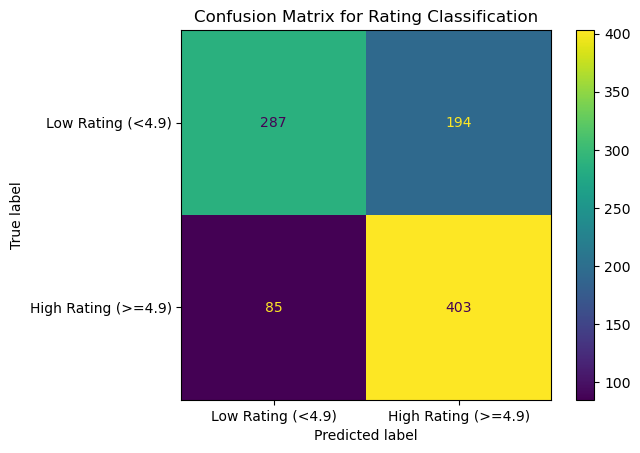

In [13]:
#  Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Low Rating (<4.9)", "High Rating (>=4.9)"]
)

plt.title("Confusion Matrix for Rating Classification")
plt.show()

In [14]:
#  Feature importance

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(importance_df.head(10))


Top Important Features:
                            Feature  Importance
7                 host_is_superhost    0.287765
8                 number_of_reviews    0.200675
0                             price    0.105739
10           number_of_reviews_l30d    0.081385
5                    minimum_nights    0.056919
6                host_response_rate    0.050094
9             number_of_reviews_ltm    0.045659
16  neighbourhood_cleansed_Belltown    0.021892
4                      accommodates    0.018871
3                              beds    0.018128


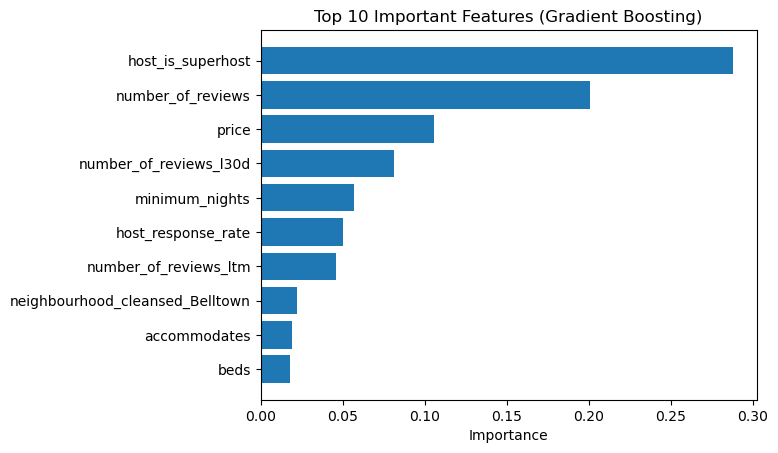

In [15]:
#  Plot feature importance

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features (Gradient Boosting)")
plt.show()

**Use Relative Price**

Accuracy: 0.7141382868937048

Confusion Matrix:
[[296 185]
 [ 92 396]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68       481
           1       0.68      0.81      0.74       488

    accuracy                           0.71       969
   macro avg       0.72      0.71      0.71       969
weighted avg       0.72      0.71      0.71       969



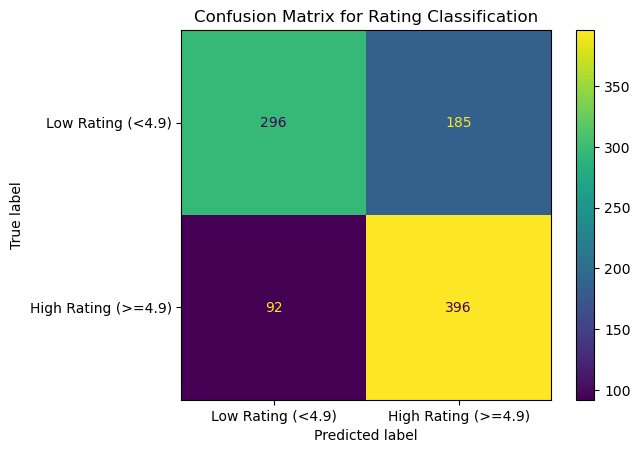


Top Important Features:
                            Feature  Importance
6                 host_is_superhost    0.290270
7                 number_of_reviews    0.188465
10                   relative_price    0.087618
9            number_of_reviews_l30d    0.083535
5                host_response_rate    0.061287
4                    minimum_nights    0.058718
8             number_of_reviews_ltm    0.043505
11           room_type_Private room    0.028020
16  neighbourhood_cleansed_Belltown    0.021044
2                              beds    0.011732


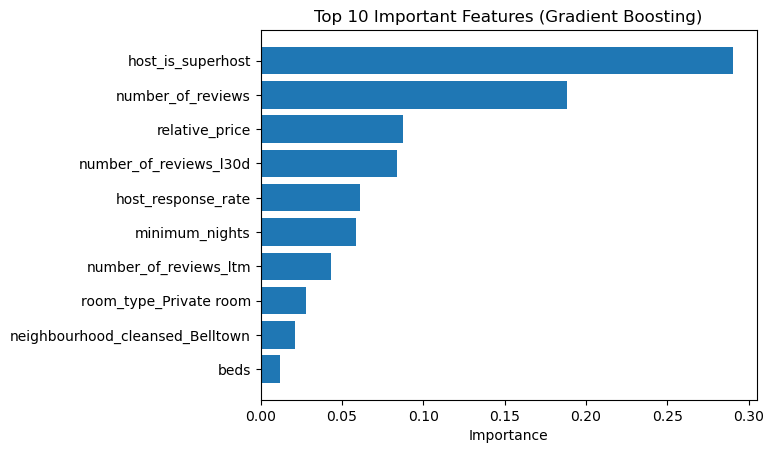

In [17]:
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]

df_relevant["avg_price_group"] = df_relevant.groupby(group_cols)["price"].transform("mean")

df_relevant["relative_price"] = df_relevant["price"] / df_relevant["avg_price_group"]

X = df_relevant.drop(columns=[
    "review_scores_rating",
    "price",
    "avg_price_group"
])
X["relative_price"] = df_relevant["relative_price"]

y = df_relevant["review_scores_rating"]
y = (y >= 4.9).astype(int)

X = pd.get_dummies(X, drop_first=True)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#  Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Low Rating (<4.9)", "High Rating (>=4.9)"]
)

plt.title("Confusion Matrix for Rating Classification")
plt.show()

#  Feature importance

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(importance_df.head(10))

#  Plot feature importance

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features (Gradient Boosting)")
plt.show()